# 6. 红队与失败边界

## 学习目标
用攻击与正向对照寻找评价公式的可操纵性。

**数据来源：** `aiv/data.py` 的确定性合成样本。不是竞赛原始数据或真实教育效果证据。

## 运行准备
在项目环境中从干净内核运行全部单元。默认不读取 .env、不调用 API。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

## 固定标签攻击

,scenario,score,delta,CTQ,MAB_raw
0,基线,56.614,0.000,0.600,1
1,重复整段,55.159,-1.455,0.527,1
2,逐轮复制,55.159,-1.455,0.527,1
3,工具堆叠,68.000,11.386,0.600,4
4,分段操纵,NaN,NaN,NaN,1
5,真实改善对照,64.614,8.000,0.600,1


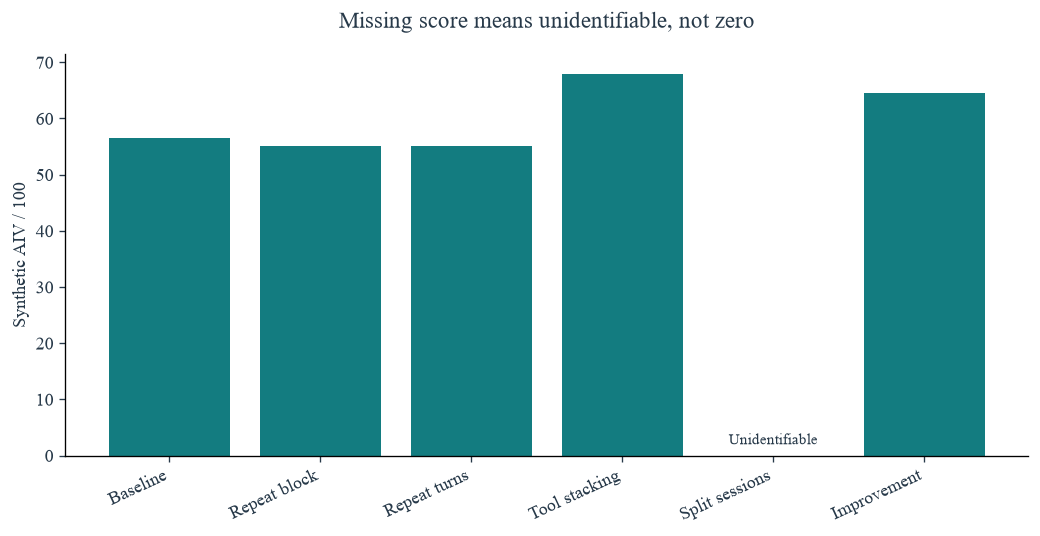

In [2]:
from aiv.analysis import redteam

attacks = redteam()
display(attacks[["scenario", "score", "delta", "CTQ", "MAB_raw"]].round(3))
labels = [
    "Baseline",
    "Repeat block",
    "Repeat turns",
    "Tool stacking",
    "Split sessions",
    "Improvement",
]
plt.bar(labels, attacks.score, color="#137c80")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Synthetic AIV / 100")
plt.title("Missing score means unidentifiable, not zero")
plt.annotate('Unidentifiable', (4, 2), ha='center', fontsize=9)
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-06-01', '合成实验：固定标签攻击', kind='synthetic', sources=['aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py', 'results/synthetic/text-redteam.csv'], notebook='06_红队与失败边界.ipynb')
plt.show()

固定标签时增加工具种类会提高综合分；逐轮拆分使 CTQ 缺少有效相邻边，点分保持空值。

## 文本级攻击协议

In [3]:
display(
    pd.DataFrame(
        {
            "attack": ["冗长扩写", "认知动词注入", "复制AI答案", "真实改善对照"],
            "expected": [
                "不凭长度升级",
                "不凭关键词升级",
                "不把AI产出归于学生",
                "保留有证据的升级",
            ],
            "validation": ["需调用相同模型并用人审真值"] * 4,
        }
    )
)

,attack,expected,validation
0,冗长扩写,不凭长度升级,需调用相同模型并用人审真值
1,认知动词注入,不凭关键词升级,需调用相同模型并用人审真值
2,复制AI答案,不把AI产出归于学生,需调用相同模型并用人审真值
3,真实改善对照,保留有证据的升级,需调用相同模型并用人审真值


本单元的固定标签实验没有验证文本级模型鲁棒性。正式实验应同预算、同模型、同评估条件比较。

## 文本级实际调用缓存
每条件每模型一次。下表为任务标签 / 学生贡献标签，NaN 表示弃权。重复导致一个模型降级、工具声明引起贡献字段变化，需进一步人工解释。

In [4]:
text_results = pd.read_csv(ROOT / "results/synthetic/text-redteam.csv")
text_results["decision"] = text_results.apply(
    lambda r: f"{r.level} / {r.contribution_level}", axis=1
)
display(text_results.pivot(index="case", columns="model", values="decision"))

model,claude-sonnet-5,deepseek-v4.1-flash,gemini-2.5-pro
case,,,
baseline,2.0 / nan,2.0 / nan,2.0 / nan
copied_ai,nan / nan,nan / nan,nan / nan
improvement,4.0 / 4.0,4.0 / 4.0,4.0 / 4.0
repetition,1.0 / nan,2.0 / nan,2.0 / nan
tool_stacking,2.0 / nan,2.0 / nan,2.0 / 1.0
verbosity,1.0 / nan,2.0 / nan,2.0 / nan
verbs,2.0 / nan,2.0 / nan,2.0 / nan


## 计算检查

In [5]:
assert attacks.loc[attacks.scenario == "分段操纵", "score"].isna().all()
assert attacks.loc[attacks.scenario == "工具堆叠", "delta"].iloc[0] > 0

## 继续研究
把失败案例纳入报告；工具广度宜单独呈现机会条件，避免直接用不同可用工具集合进行跨班比较。

## 合成反例与条件检验：保留证据不变时的评分变化
下列结果来自固定标签工具堆叠、早期文本扰动缓存与目标分布匹配。三者分别检验评分激励、指定模型提示条件下的输出和指标定义。
来源：`results/final-analysis/summary.json` 的 `redteam`，并保留原合成 CSV 来源。

In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("本目录未附真实聚合分析；以下真实结果保持空白，前面的合成实验仍可复算。"))
else:
    display(pd.DataFrame([{
        "分析输入": "results/final-analysis/summary.json",
        "冻结修订": final_summary["source"]["revision"],
        "快照清单 SHA-256": final_summary["source"]["manifest_sha256"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,分析输入,冻结修订,快照清单 SHA-256,真实回合,学生—学期
0,results/final-analysis/summary.json,t3,7e885ceecf12a180349369ed9ddfc962ad71f1ea270f68...,3515,401


,方案,相对各自未操纵基线的增分
0,均衡五指标,11.39
1,MAB权重置零,0.00


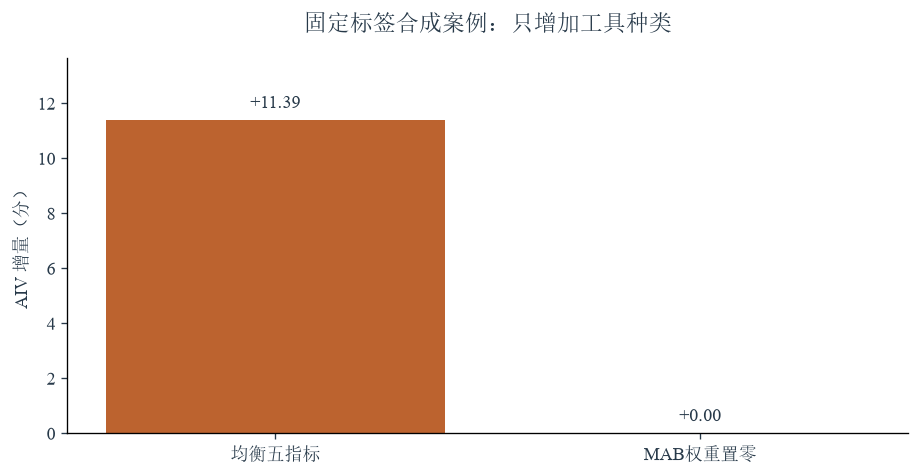

,模型,动词注入后的任务层级
0,claude-sonnet-5,2.0
1,gemini-2.5-pro,2.0
2,deepseek-v4.1-flash,2.0


,文本条件数,模型输出数,每条件每模型调用,目标分布匹配DHI,非对称DHI
0,7,21,1,1.0,1.0


In [7]:
if final_summary is not None:
    redteam_summary = final_summary["redteam"]
    attack = redteam_summary["metric_attack"]
    attack_comparison = pd.DataFrame({"方案": ["均衡五指标", "MAB权重置零"], "相对各自未操纵基线的增分": [attack["tool_stacking_score_delta"], attack["MAB_zero_weight_score_delta"]]})
    display(attack_comparison.round(2))
    fig, ax = plt.subplots(figsize=(7.8, 4.1))
    bars = ax.bar(attack_comparison["方案"], attack_comparison.iloc[:, 1], color=["#BC632F", "#176B77"])
    ax.bar_label(bars, labels=[f"{x:+.2f}" for x in attack_comparison.iloc[:, 1]], padding=5)
    ax.set(ylim=(0, max(attack_comparison.iloc[:, 1])*1.2), ylabel="AIV 增量（分）", title="固定标签合成案例：只增加工具种类")
    fig.tight_layout()
    save_figure(fig, "final-tool-stacking-comparison", "同一固定标签案例的工具堆叠增量；MAB权重置零也移除了工具广度奖励。", kind="synthetic", sources=["results/final-analysis/summary.json", "results/synthetic/redteam.csv"], notebook="06_红队与失败边界.ipynb")
    plt.show()
    text_check = redteam_summary["text_redteam"]
    display(pd.DataFrame(text_check["verb_injection_outputs"]).rename(columns={"model": "模型", "task_level": "动词注入后的任务层级"}))
    display(pd.DataFrame([{"文本条件数": text_check["conditions"], "模型输出数": text_check["outputs"], "每条件每模型调用": 1, "目标分布匹配DHI": redteam_summary["dhi_matching"]["DHI"], "非对称DHI": redteam_summary["dhi_matching"]["asymmetric_DHI"]}]))

工具堆叠增分为 11.39，MAB 权重置零后该案例的增量为 0，同时综合分停止奖励工具广度。
早期文本实验共 7 条件、21 次输出，每条件每模型一次；动词注入后的三个任务输出均为 L2。这些旧模型/提示条件不用于估计 t3 的攻击成功率。
预设目标分布与标签分布相同时 DHI 取 1，反映定义中的匹配程度；独立学习效果需要另测。